In [6]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.features.build_features import _index_dataframe_by_columns_values

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
### DEFINE VARIABLES ###

model_parent = 'reading_late_april'

models = glob.glob(os.path.join(Defaults.MODEL_DIR, model_parent, '*'))


### Load Results

In [7]:

# load model results
data = pd.DataFrame()
for model in models:
    # read model summary into pd dataframe
    df = pd.read_csv(os.path.join(model, 'model-summary.csv'), engine='python')

    df['features'] = df['feat_spec_name'].str.replace('features-', '')
    df['features'] = df['features'].str.replace('-remove-total-scores', '')
    df['demos'] = df['spec_name'].str.replace('participants-Reading-', '').str.replace('-spec', '')
    df['model_dir'] = model
    df['readers'] = df['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

    # append dataframe
    data = pd.concat([data, df])

data['features'] = data['features'].str.replace('achievement', 'reading')
    


In [5]:
data['features'].unique()

array(['Child', 'Parent', 'Teacher', 'Parent-SES', 'all-demos',
       'child-anxiety', 'child-cbcl', 'Child-emotional-status',
       'Child-executive-function', 'Child-intelligence',
       'Child-production', 'Child-reading', 'Child-reading-all-CORRECT',
       'all-internalizing-externalizing', 'Parent-Stress',
       'Parent-Psychological-Function', 'Parent-CBCL', 'Child-language',
       'Parent-Intake-Interview', 'Parent-Family-History'], dtype=object)

### Firstlevel models (classifiers)

Best classifier is `RandomForestClassifier` across `Child` `Parent` and `Teacher` assessments

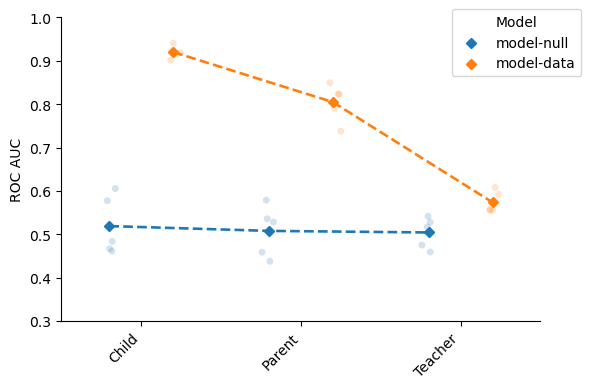

In [6]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter, 
            y='roc_auc_score', 
            x='features', 
            hue='data', 
            fig_title='',
            legend_title='Model', 
            join_lines=True,
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            scale=0.7,
            figsize=(6,4)
            )

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


## Compare Child-Parent-Teacher Models `RandomForestClassifier`

In [ ]:
#### STATS ####

from scipy import stats as sp

child = df_filter[df_filter['features']=='Child']
parent = df_filter[df_filter['features']=='Parent']
teacher = df_filter[df_filter['features']=='Teacher']

# calculate the F test - one way ANOVA
result = sp.f_oneway(child['roc_auc_score'], parent['roc_auc_score'], teacher['roc_auc_score'])
print(f'F test for evaluation between males and females: {result}')


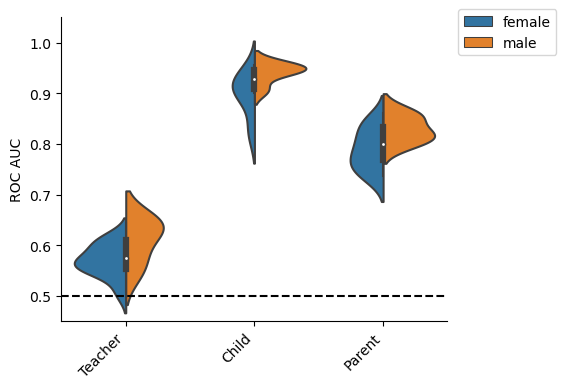

In [5]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()

fig = vis.violinplot(
    x='features', 
    y='roc_auc_score', 
    hue='Sex', 
    ylim=[0.45,1.05], 
    ylabel='ROC AUC',
    xlabel='', 
    data=df_filter, 
    fig_title='', 
    # join_lines=True,
    # legend_title='Sex',
    figsize=(6,4)
    )

# reordering the labels 
handles, _ = fig.figure.gca().get_legend_handles_labels() 
  
# specify order 
# order = [0,1] 
# labels = ['male', 'female']
  
# # pass handle & labels lists along with order as below 
# plt.legend([handles[i] for i in order], [labels[i] for i in order]) 

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-assessments-male-female.png'), bbox_inches='tight')


In [ ]:
# #### STATS ####

# from scipy import stats as sp

# # calculate the F test - one way ANOVA
# result = sp.f_oneway(df_filter[df_filter['Sex']=='male']['roc_auc_score'], df_filter[df_filter['Sex']=='female']['roc_auc_score'])
# print(f'F test for evaluation between males and females: {result}')

# # calculate the T test - paired t-test
# tests = ['Child', 'Parent', 'Teacher']
# for test in tests:
#     df1 = df_filter[df_filter['features']==test]
#     result = sp.ttest_rel(df1[df1['Sex']=='male']['roc_auc_score'], df1[df1['Sex']=='female']['roc_auc_score'], nan_policy='omit')
#     print(f'T test for evaluation between males and females for {test}: {result}')


## Firstlevel models - Best Classifier - `RandomForestClassifier` - All Sexes - All Ages - All Races

* Best models in classifying reading impairment are: 
    * intelligence
    * executive function
    * achievement
    * emotional status
    * parent report - child mind institute questionnaire. 
* Worst models in classifying reading impairment are:
    * internalizing
    * externalizing
    * production
    * basic demographics
    * child cbcl questionnaire

## Firstlevel models - Best Classifier - `RandomForestClassifier` - Separate models for Males and Females - All Ages - All Races


In [ ]:
data['features'].unique()

## Child Models

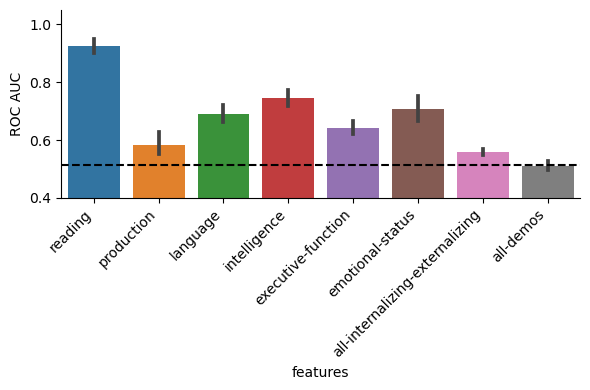

In [8]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-language', 'Child-production', 
    'Child-intelligence', 'Child-executive-function',
    'Child-emotional-status', 'all-demos', 'Child-reading', 'all-internalizing-externalizing']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()
df_filter['features'] = df_filter['features'].str.replace('Child-', '')

fig = vis.barplot(
            data=df_filter[df_filter['data']=='model-data'].sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            # hue='Sex', 
            # fig_title='',
            # legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            ylim=[.4, 1.05],
            # join_lines=False,
            # markers="D",
            # scale=0.6,
            figsize=(6,4)
            )

# plot null model
null = df_filter[df_filter['data']=='model-null'].groupby('features')['roc_auc_score'].mean().values
plt.axhline(y=null.mean(), color='k', linestyle='--')

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-child-measures.png'), bbox_inches='tight')

In [48]:
from scipy.stats import ttest_ind
import numpy as np

reading = df_filter[(df_filter['data']=='model-data') & (df_filter['features']=='reading')]['roc_auc_score'].values
other = df_filter[(df_filter['data']=='model-data') & (df_filter['features']!='reading')]
other_measures = np.array(pd.pivot_table(other, values='roc_auc_score', index=['splits'], columns=['features'])).mean(axis=1)

# Bonferroni correction
def t_test_bonferroni(group1, group2, num_comparisons=None, alpha=0.05):
  statistic, p_value = ttest_ind(group1, group2, nan_policy='omit')
  if num_comparisons is not None:
    corrected_p_val = p_value * num_comparisons
    print(f'T-statistic: {statistic:.4f}, p-value: {p_value:.4f}, corrected p-value: {corrected_p_val:.4f}, significance: {significance}')
  else:
    corrected_p_val = None
    print(f'T-statistic: {statistic:.4f}, p-value: {p_value:.4f}')

  return statistic, p_value, corrected_p_val

# Correct for multiple comparisons
stat, p_val, corrected_p_val = t_test_bonferroni(reading, other_measures, num_comparisons=None, alpha=0.05)


T-statistic: 18.9589, p-value: 0.0000


## Parent Models 

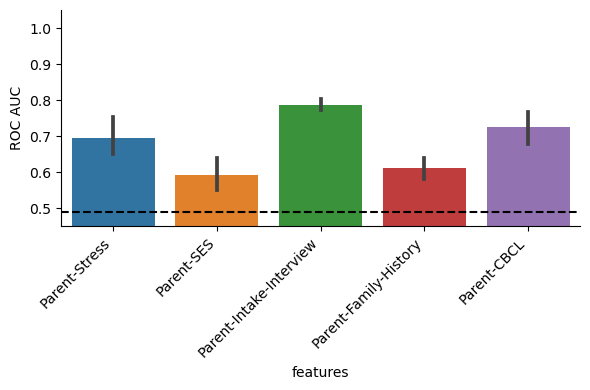

In [31]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male', 'female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Parent-SES', 'Parent-Stress', 'Parent-Intake-Interview', 
     'Parent-Family-History',  'Parent-CBCL']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()
df_filter['features'] = df_filter['features'].str.replace('Child-', '')

fig = vis.barplot(
            data=df_filter[df_filter['data']=='model-data'].sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            # hue='Sex', 
            # fig_title='',
            # legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            ylim=[.45, 1.05],
            # join_lines=False,
            # markers="D",
            # scale=0.6,
            figsize=(6,4)
            )
# plot null model
null = df_filter[df_filter['data']=='model-null'].groupby('features')['roc_auc_score'].mean().values
plt.axhline(y=null.mean(), color='k', linestyle='--')

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-parent-measures.png'), bbox_inches='tight')

## Early - Emerging - Fluent Readers

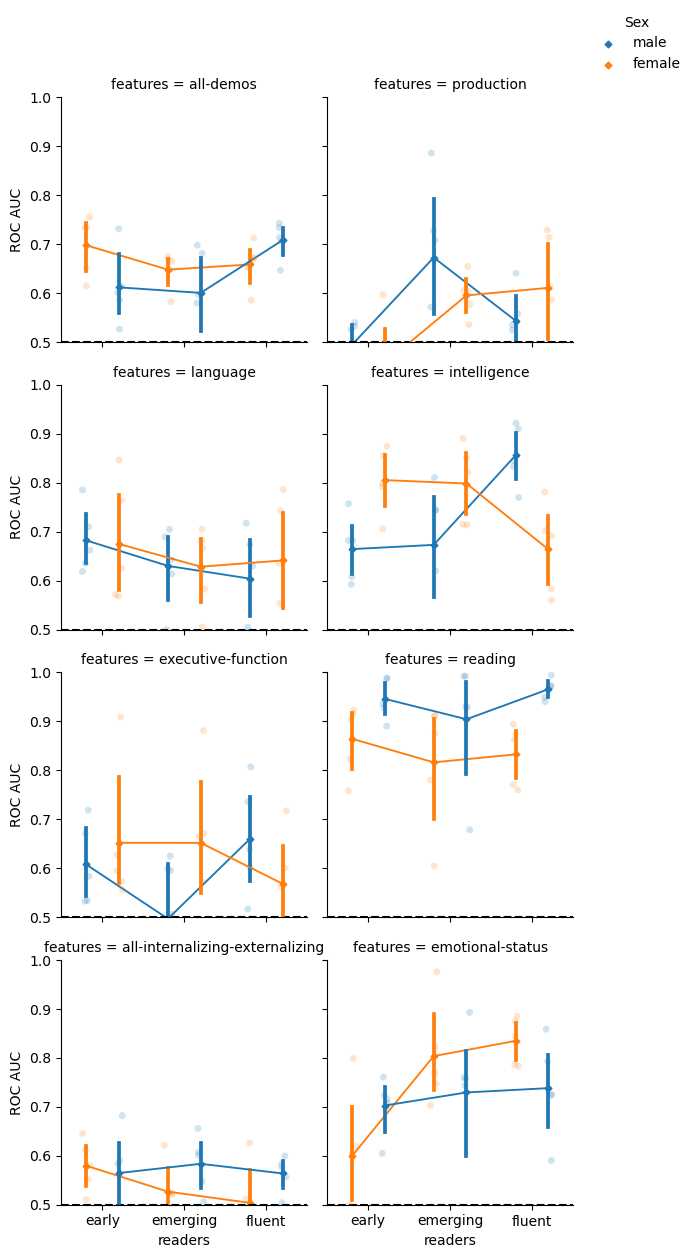

In [29]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-language', 'Child-production', 
    'Child-intelligence', 'Child-executive-function',
    'Child-emotional-status', 'all-demos', 'Child-reading', 'all-internalizing-externalizing']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}


g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
g.set(ylim=(0.5, 1.0))
g.despine()
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-development-male-female-1.png'), bbox_inches='tight')

    

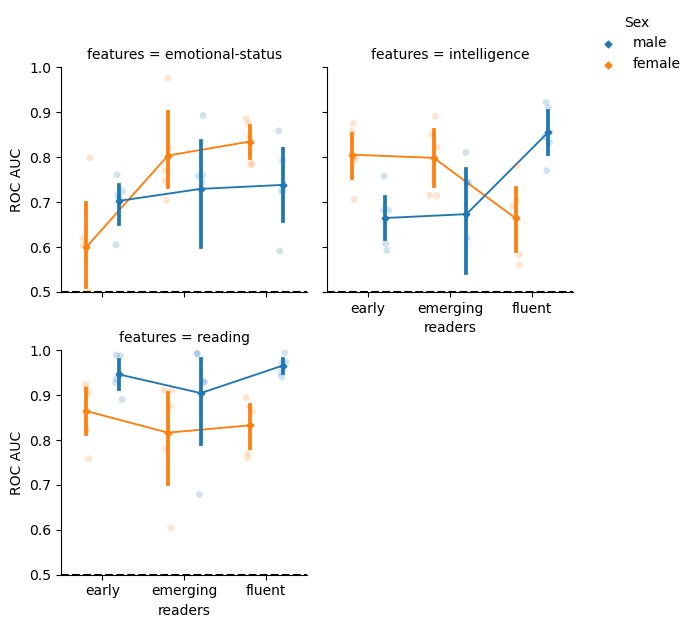

In [28]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-emotional-status', 'Child-reading', 'Child-intelligence']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}


g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
g.despine()
g.set(ylim=(0.5, 1.0))
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-development-male-female-2.png'), bbox_inches='tight')

    

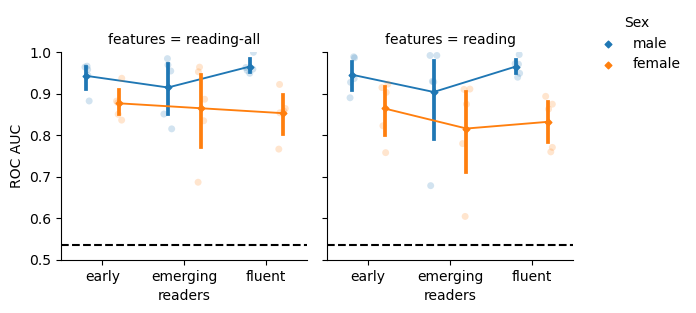

In [27]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-reading', 'Child-reading-all-CORRECT']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'] \
                        .str.replace('Child-', '') \
                        .str.replace('reading-all-CORRECT', 'reading-all')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}

# plot null model
null = df_filter[df_filter['data']=='model-null'].groupby(['features', 'Sex', 'readers'])['roc_auc_score'].mean().values


g = sns.FacetGrid(df_filter[df_filter['data']=='model-data'].sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.refline(y=null.mean(), color='black', linestyle='--')
g.set_ylabels('ROC AUC')
g.set(ylim=(0.5, 1.0))
g.despine()
g.fig.subplots_adjust(right=0.8)
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()

g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-development-male-female-3.png'), bbox_inches='tight')

    

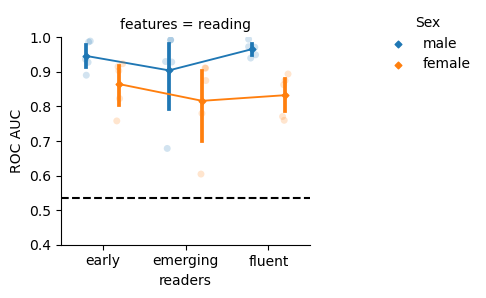

In [37]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-reading']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'] \
                        .str.replace('Child-', '') \

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}

# plot null model
null = df_filter[df_filter['data']=='model-null'].groupby(['features', 'Sex', 'readers'])['roc_auc_score'].mean().values


g = sns.FacetGrid(df_filter[df_filter['data']=='model-data'].sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True,
                alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex',
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.refline(y=null.mean(), color='black', linestyle='--')
g.set_ylabels('ROC AUC')
g.set(ylim=(0.4, 1.0))
g.despine()
g.fig.subplots_adjust(right=0.8)
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(.7, 1), title='Sex', label_order=['male', 'female'])
g.tight_layout()

g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-development-male-female-3.png'), bbox_inches='tight')

    

In [17]:
df_groups = df_filter[df_filter['data']=='model-data'].groupby(['Sex', 'readers', 'splits'])['roc_auc_score'].mean().reset_index()


def two_way_anova(data, dependent_var, factor1, factor2):
    """
    Performs a two-way ANOVA test.

    Args:
        data: A pandas DataFrame containing the data.
        dependent_var: The name of the column containing the dependent variable.
        factor1: The name of the first factor column.
        factor2: The name of the second factor column.

    Returns:
        A pandas DataFrame containing the ANOVA table.
    """
    import pandas as pd
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    # Define the formula for the linear model
    formula = f"{dependent_var} ~ {factor1} + {factor2} + {factor1}:{factor2}"

    # Create the linear model
    model = ols(formula, data=data).fit()

    # Perform the ANOVA test
    anova_table = anova_lm(model)

    return anova_table

anova_results = two_way_anova(df_groups, "roc_auc_score", "Sex", "readers")
print(anova_results)



               df    sum_sq   mean_sq          F    PR(>F)
Sex           1.0  0.076361  0.076361  10.158349  0.003961
readers       2.0  0.011902  0.005951   0.791650  0.464575
Sex:readers   2.0  0.003938  0.001969   0.261958  0.771715
Residual     24.0  0.180411  0.007517        NaN       NaN


In [14]:
df_groups.groupby(['Sex', 'readers'])['roc_auc_score'].mean()

Sex     readers 
female  early       0.729833
        emerging    0.744240
        fluent      0.702788
male    early       0.717388
        emerging    0.706009
        fluent      0.726424
Name: roc_auc_score, dtype: float64

In [ ]:
#### STATS ####

from scipy import stats as sp

groups = df_filter.groupby(['Sex', 'readers'])['roc_auc_score']
means = groups.mean().reset_index()

# calculate the F test - one way ANOVA
result = sp.f_oneway(gender_means[gender_means['Sex']=='male']['roc_auc_score'], gender_means[gender_means['Sex']=='female']['roc_auc_score'])
# result = sp.f_oneway(df_filter[df_filter['Sex']=='male']['roc_auc_score'], df_filter[df_filter['Sex']=='female']['roc_auc_score'])
print(f'F test for evaluation between males and females: {result}')

# calculate the T test - paired t-test
tests = ['language', 'production',
       'intelligence', 'executive-function',
       'reading', 'emotional-status', 'cbcl']
for test in tests:
    df1 = df_filter[df_filter['features']==test]
    result = sp.ttest_rel(df1[df1['Sex']=='male']['roc_auc_score'], df1[df1['Sex']=='female']['roc_auc_score'], nan_policy='omit')
    print(f'T test for evaluation between males and females for {test}: {result}')


In [ ]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-language', 'Child-production', 
    'Child-intelligence', 'Child-executive-function',
    'Child-emotional-status', 'all-demos', 'Child-reading']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.3, 1],
            scale=0.5,
            dodge=0.4,
            figsize=(6,4)
            )
fig.axhline(y=0.5, color='black', linestyle='--')


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-development-best.png'), bbox_inches='tight')

In [ ]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-reading', 'Child-reading-all-CORRECT']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'] \
                        .str.replace('Child-', '') \
                        .str.replace('reading-all-CORRECT', 'reading-all')

# change color style


fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.8, 1],
            scale=0.5,
            dodge=0.4,
            figsize=(5,3)
            )
fig.axhline(y=0.5, color='black', linestyle='--')


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-full-reading-abridged-ages.png'), bbox_inches='tight')

In [ ]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}


g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.refline(y=0.5, color='black', linestyle='--')
g.set_ylabels('ROC AUC')
g.despine()
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()

g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-development-male-female-assessments.png'), bbox_inches='tight')

    

In [ ]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.4, 1],
            scale=0.6,
            dodge=0.4,
            figsize=(5,4)
            )
fig.axhline(y=0.5, color='black', linestyle='--')


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-development-assessments.png'), bbox_inches='tight')

In [ ]:
# do stats
from scipy import stats as sp

# loop through features
feat_list = ['Child-reading', 'Child-intelligence', 'Child-emotional-status', 'Child-executive-function', 'Reading-all']
for feat in feat_list:

    df1 = _index_dataframe_by_columns_values(dataframe=df_filter, columns=['features'], values_list=[[feat]])

    # calculate the F test - one way ANOVA
    result = sp.f_oneway(df1[df1['readers']=='early']['roc_auc_score'], 
                         df1[df1['readers']=='emerging']['roc_auc_score'],
                         df1[df1['readers']=='emerging']['roc_auc_score'])
    print(f'F test for evaluation between early, emerging and fluent readers for {feat}: {result}')

In [ ]:
# do stats
from scipy import stats as sp

# calculate the F test - one way ANOVA
result = sp.f_oneway(df_filter[df_filter['readers']=='early']['roc_auc_score'], 
                        df_filter[df_filter['readers']=='emerging']['roc_auc_score'],
                        df_filter[df_filter['readers']=='emerging']['roc_auc_score'])
print(f'F test for evaluation between early, emerging and fluent readers: {result}')

## Feature Importances for Best Models

In [ ]:
# # select model name based on conditionals

# columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
# values_list = [
#     ['RandomForestClassifier'],
#     ['model-data'],
#     ['male_female'],
#     ['all'],
#     ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
#     ['secondlevel'],
#     ['Child-reading']
#     # ['Child-remove-total-scores']
#     ]

# df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

# dirs = df_filter['model_dir'].unique()
# print(dirs)

# for (reader, model_dir) in zip(['early', 'emerging', 'fluent'], dirs):

#     # load feature importances 
#     features = pd.read_csv(os.path.join(model_dir,  'feature_importance.csv'), engine='python')

#     # sort values
#     features = features.sort_values(by='feature_importances', ascending=False)

#     # visualize feature importances
#     fig = vis.barplot(data=features, top_features=25, figsize=(8,4), title=reader)
#     # fig.figure.savefig(os.path.join(Defaults.FIG_DIR, f'feature_importances-{reader}-Reading-all-model.png'), bbox_inches='tight')

In [ ]:
# columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
# values_list = [
#     ['RandomForestClassifier'],
#     ['model-data'],
#     ['male_female'],
#     ['all'],
#     ['6_7_8', '11_12_13_14_15_16_17_18'],
#     ['firstlevel'],
#     ['Child-reading']
#     ]

# df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

# dirs = df_filter['model_dir'].unique()
# print(dirs)

# features_all = pd.DataFrame()
# for model_dir in dirs:

#     # load feature importances 
#     features = pd.read_csv(os.path.join(model_dir,  'feature_importance.csv'), engine='python')

#     # sort values
#     features = features.sort_values(by='feature_importances', ascending=False)

#     # concat features
#     features_all = pd.concat([features_all, features])

# # remap age -> readers
# features_all['readers'] = features_all['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

# # remove `numeric__`
# features_all['feature_importances_names'] = features_all['feature_importances_names'].str.replace('numeric__', '')

# # only take top features
# features_all = features_all[features_all['top_features']==True]

# fig = vis.pointplot(data=features_all, 
#             y='feature_importances', 
#             x='readers', 
#             hue='feature_importances_names',
#             fig_title='', 
#             legend_title='Features', 
#             ylim=None, 
#             xlabel=None,  
#             ylabel='Feature Importances', 
#             markers="o",
#             linestyles="--",
#             join_lines=True,
#             scale=0.5,
#             alpha=0,
#             dodge=False,
#             figsize=(8,4)
#             )

# # fig = plt.gcf()
# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, f'feature_importances-readers-Reading-all-model.png'), bbox_inches='tight')

## Test Predictions

In [ ]:
# select model name based on conditionals

columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-language',
       'all-internalizing', 'all-externalizing', 'Child-production',
       'Child-intelligence', 'Child-executive-function',
       'Child-reading', 'Child-emotional-status', 'all-demos',
       'parent-child-mind-institute', 'child-cbcl']
    # ['Child-remove-total-scores']
    ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

dirs = df_filter['model_dir'].unique()
print(dirs)

In [ ]:
## load evaluation and predictions

def load_evaluation(models):
    # load model evaluation
    data_eval = pd.DataFrame()
    for model in models:
        try:
            # read model summary into pd dataframe
            df = pd.read_csv(os.path.join(model, 'model_evaluation.csv'), engine='python')

            df['model_dir'] = model
        
            # append dataframe
            
            data_eval = pd.concat([data_eval, df])
        except:
            data_eval = None
    
    return data_eval

def load_predictions(models):

    # load demographics for test participants
    df_demos = pd.read_csv(os.path.join(Defaults.INTERIM_DIR, 'phenotypes', 'all_participant_diagnoses.csv'), engine='python')
    df_grouped = df_demos.groupby('Identifiers')
    first_instances = df_grouped.head(1)

    # load model predictions
    data_pred = pd.DataFrame()
    for model in models:

        # read model summary into pd dataframe
        df = pd.read_csv(os.path.join(model, 'model_predictions.csv'), engine='python')
        df['model_dir'] = model

        # load participant index
        df_index = pd.read_csv(os.path.join(model, 'participant_index.csv'), engine='python')

        df_part = df_index[df_index['split']=='test'].reset_index(drop=True)
        cols_to_keep = [col for col in df_part.columns if 'DX_Cat_Name' not in col]

        df_merged = pd.concat([df, df_part[cols_to_keep]], axis=1)
        df_merged_demos = first_instances.merge(df_merged, on='Identifiers')
    
        # append dataframe
        data_pred = pd.concat([data_pred, df_merged_demos]).reset_index(drop=True)
    
    # add new col
    data_pred['correct_prediction'] = data_pred['y_pred']==data_pred['y_test']

    

    return data_pred